In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import Gaussian2DKernel, Box1DKernel, convolve, convolve_fft
import astropy.constants as const
import astropy.units as u
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit


In [2]:
def makegauss(v, amp,vcen,fwhm): # unit, km/s, km/s
    sig = 1./(2.*np.sqrt(2*np.log(2)))*fwhm
    y = np.exp(-(v-vcen)**2./(2*sig**2))*amp
    return v,y

In [3]:
makegauss(np.arange(-10,10,1), 1,0,1)

(array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9]),
 array([3.87259191e-121, 2.92604772e-098, 8.63616856e-078, 9.95682444e-060,
        4.48415509e-044, 7.88860905e-031, 5.42101086e-020, 1.45519152e-011,
        1.52587891e-005, 6.25000000e-002, 1.00000000e+000, 6.25000000e-002,
        1.52587891e-005, 1.45519152e-011, 5.42101086e-020, 7.88860905e-031,
        4.48415509e-044, 9.95682444e-060, 8.63616856e-078, 2.92604772e-098]))

In [4]:
def makegaussfit(v, amp,vcen,fwhm ): # unit, km/s, km/s
    sig = 1./(2.*np.sqrt(2*np.log(2)))*fwhm
    y = np.exp(-(v-vcen)**2./(2*sig**2))*amp
    return y
def mygaussfit(x,y):
    popt, pcov = curve_fit(makegaussfit, x, y, p0 = [1,0,20])
    return popt

In [5]:
def lnprior1(para):
    vcen,fwhm,amp1,amp2,amp3,amp4 = para
    if (-10 < amp1 < 10 and
            -5 < vcen < 5 and 0.5 < fwhm < 2):
        return 0.0
    return -np.inf


In [6]:
def log_prob(para, obs):
    # create model line
    _,y1mod = makegauss(obs[0][0],para[2],para[0],para[1])
    _,y2mod = makegauss(obs[1][0],para[3],para[0],para[1])
    _,y3mod = makegauss(obs[2][0],para[4],para[0],para[1])
    _,y4mod = makegauss(obs[3][0],para[5],para[0],para[1])
    mod = [y1mod,y2mod,y3mod,y4mod]
    # interpolate to different frequencies
    logprob = []
    for _obs,_mod in zip(obs,mod):
        # calculate log probability
        logprob.append(np.sum(-0.5*(((_obs[1]-_mod)/_obs[2])**2.+np.log(np.median(_obs[2])))))
        # return sum
    return np.array(logprob).sum()+lnprior1(para)  if np.isfinite(np.array(logprob).sum()) else -np.inf


iamp  = np.arange(0,0.05,0.001)
ivcen = np.arange(-10,10,2)
ifwhm = np.arange(0,60,3)
amp = 0.02
vcen = 0
fwhm = 30

fig= plt.figure()
ax = fig.add_subplot(311)
for _amp in iamp:
    ax.scatter(_amp,log_prob([_amp,vcen,fwhm],ftbl, fobs, obs,0.001))
    ax.scatter(_amp,log_prob([_amp,3,fwhm],ftbl, fobs, obs,0.001))


ax = fig.add_subplot(312)
for _vcen in ivcen:
    ax.scatter(_vcen,log_prob([amp,_vcen,fwhm],ftbl, fobs, obs,0.001))


ax = fig.add_subplot(313)
for _fwhm in ifwhm:
    ax.scatter(_fwhm,log_prob([amp,vcen,_fwhm],ftbl, fobs, obs,0.001))
    ax.scatter(_fwhm,log_prob([amp,3,_fwhm],ftbl, fobs, obs,0.001))


plt.tight_layout()

ftbl = np.genfromtxt('/Users/mrugel/Documents/LocalFiles/postdoc_bonn/meerkat/notes_meerkat_2021/splatalogue.tsv')

In [7]:
ftbl = np.genfromtxt('/Users/mrugel/Documents/LocalFiles/postdoc_bonn/meerkat/notes_meerkat_2021/splatalogue.tsv')

In [8]:
#ftbl

In [9]:
#ftbl = np.array([[2.422463,np.nan]])

Observed frequencies

In [10]:
chwidth = 26.123*1000*8
fobs = np.arange(32768/8)*chwidth+2.3e9

## Make Line

In [11]:
rms=0.001

In [12]:
v=np.arange(-200,200,.5)

(-10.0, 10.0)

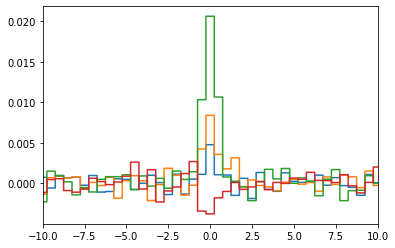

In [13]:
# global properties
vcen=0
fwhm=1.0

#1612
amp1= 0.003
v1,y1 = makegauss(v,amp1,vcen,fwhm)
y1obs = y1+np.random.normal(0,1,len(v))*rms
rms1 = np.ones_like(v1)*rms

#1665
amp2 = 0.01
v2,y2 = makegauss(v,amp2,vcen,fwhm)
y2obs = y2+np.random.normal(0,1,len(v))*rms
rms2 = np.ones_like(v2)*rms

#1667
amp3 = 0.02
v3,y3 = makegauss(v,amp3,vcen,fwhm)
y3obs = y3+np.random.normal(0,1,len(v))*rms
rms3 = np.ones_like(v3)*rms

#1720
amp4 = -0.003
v4,y4 = makegauss(v,amp4,vcen,fwhm)
y4obs = y4+np.random.normal(0,1,len(v))*rms
rms4 = np.ones_like(v4)*rms

# collect all models
obs = [[v1,y1obs,rms1],[v2,y2obs,rms2],[v3,y3obs,rms3],[v4,y4obs,rms4]]

# plot
plt.close('all')
for _out in obs:
    plt.step(_out[0], _out[1],where='mid')
plt.xlim([-10,10])

### Noise properties

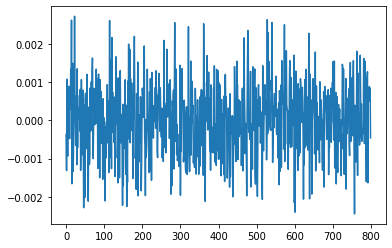

In [14]:
plt.plot(np.random.normal(0,1,len(v))*rms)

(array([  5.,  22.,  74., 134., 170., 163., 117.,  69.,  40.,   6.]),
 array([-2.86182044e-03, -2.30081335e-03, -1.73980625e-03, -1.17879916e-03,
        -6.17792069e-04, -5.67849770e-05,  5.04222115e-04,  1.06522921e-03,
         1.62623630e-03,  2.18724339e-03,  2.74825048e-03]),
 <BarContainer object of 10 artists>)

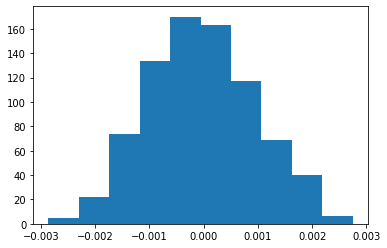

In [15]:
plt.hist(np.random.normal(0,1,len(v))*rms)

## EMCEE

In [16]:
ndim = 6
nwalkers = 32
p0 = np.random.rand(nwalkers, ndim)-0.5
p0 = np.array(p0)
#CENTRAL VELOCITY
p0[:,0] = p0[:,0]
#LINEWIDTH
p0[:,1] = p0[:,1]+1
#AMPLITUDE
p0[:,2] = p0[:,2]
p0[:,3] = p0[:,3]
p0[:,4] = p0[:,4]
p0[:,5] = p0[:,5]

In [17]:
p0

array([[-0.20597392,  0.90664526,  0.39462468,  0.22514604, -0.16393733,
        -0.45689405],
       [-0.34932868,  0.65557297,  0.27269912,  0.14267731, -0.0651268 ,
         0.43492845],
       [-0.36801203,  1.24269492, -0.33028368, -0.05940327,  0.31435025,
        -0.40105595],
       [ 0.03560834,  1.19935103,  0.35555709,  0.07791319, -0.2642502 ,
        -0.31064175],
       [ 0.09969917,  1.07990935, -0.12835288,  0.49106348, -0.31659421,
         0.31529463],
       [-0.35018924,  1.41834014, -0.39403894, -0.08568619, -0.02273442,
         0.39002919],
       [ 0.28195741,  0.89519688, -0.43170777, -0.33202533,  0.18749686,
         0.11422081],
       [ 0.22761239,  0.94329921,  0.26062523, -0.21430034,  0.33471061,
         0.21347908],
       [ 0.34552929,  1.45716398,  0.45633674, -0.34473232,  0.29665112,
        -0.41339648],
       [ 0.15478186,  1.04772082,  0.39548676, -0.19128969,  0.36008813,
         0.07550368],
       [ 0.17435338,  1.1683428 , -0.14848362, -0.

In [18]:
import emcee
from multiprocessing.pool import Pool
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[obs],pool=Pool(8))
pos, prop, state = sampler.run_mcmc(p0, 100, progress=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 131.01it/s]


In [19]:
sampler.reset()

In [20]:
pos, prop, state = sampler.run_mcmc(p0, 2000, progress=True, rstate0=state)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:14<00:00, 136.51it/s]


In [21]:
flat_samples = sampler.get_chain(discard=200, thin=15, flat=True)
print(flat_samples.shape)

(3840, 6)


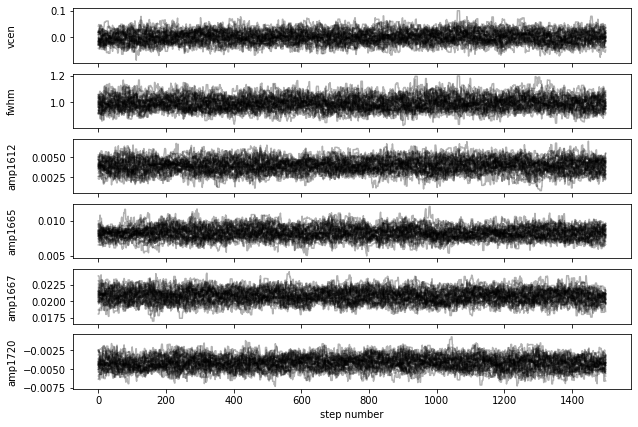

In [22]:
fig, axes = plt.subplots(6, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["vcen", "fwhm", "amp1612","amp1665", "amp1667", "amp1720"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[500:,:, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

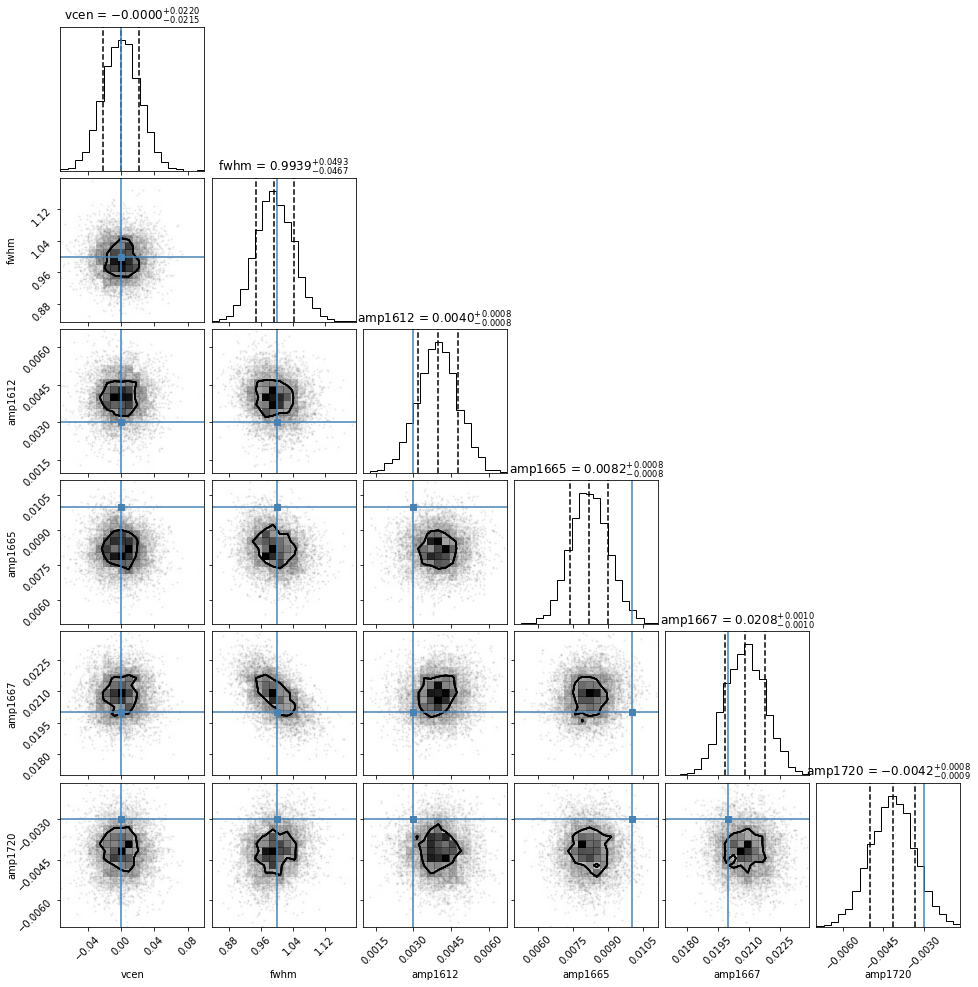

In [23]:
import corner

fig = corner.corner(
    flat_samples, labels=labels,truths=[vcen,fwhm,amp1,amp2,amp3,amp4],quantiles=[0.16,0.5,0.84], levels=[1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5)],show_titles=True, title_fmt='.4f')
